# Student Risk Model Comparison and Optimization

This notebook demonstrates a full machine learning workflow for student risk prediction, including model training, selection, and optimization using XGBoost, Logistic Regression, Random Forest, and MLP. Advanced techniques such as SMOTE, cost-sensitive training, and hyperparameter tuning are applied.

## 1. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, roc_curve, auc,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score)
from scipy.stats import randint
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from collections import Counter
from IPython.display import display, Markdown
import joblib
from xgboost import XGBClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

# Dictionary to store all results
models_and_results = {}
models_to_save = {}
scalers_to_save = {}

# Feature selection parameters
feature_selection_params = {
    'threshold': 0.005
}


## 2. Load and Prepare Data

In [33]:
# df.to_csv('/content/drive/My Drive/first_time_students.csv', index=False)
df = pd.read_csv('first_time_stud_latest.csv')
columns = ['StudentNumber','Id','Name','Surname','Gender','FTEN','LecturerTitle','Language','Race','DoB','MatricDate',
	         'AcademicYear','Age','GapYears','QualCode','Qualification','DepartCode','Department','FacultyCode','Faculty',
           'OfferingType','CampusName','StudyPeriod','QualType','PostGrad','MatricType','SubsidyType','OfferringType','classGoup',
           'FullPartTime','ExamMonth','FinalMark','FullPeriodmark','StatsCredit','Quintile','FinalYearStatus','PreviousActivity',
           'Religion','EndYear','ExaminingAuthority','PreparationTime','ExperientialTime','FormalTime','StudentType','ResidenceIndicator',
           'MaritalStatus','MatricDescrip','FundingSource','StudentTypeDescription','CreatedbyWeb','StudentFoundation','FirstEntryYear',
           'FinalYearSymbol','SubjectCode','Mark1','Mark2','Mark3','Mark4','AverageMark','PassFail']

# Load the CSV
df = pd.read_csv('first_time_stud_latest.csv', header=None, names=columns,low_memory=False)
# files.download('/content/drive/My Drive/first_time_students.csv')

C:\Users\trymoren\AppData\Local\Temp\ipykernel_14384\4278933460.py:2: DtypeWarning: Columns (0: 7703230327084) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('first_time_stud_latest.csv')


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 823520 entries, 0 to 823519
Data columns (total 60 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   StudentNumber           823520 non-null  int64  
 1   Id                      822313 non-null  str    
 2   Name                    823520 non-null  str    
 3   Surname                 823499 non-null  str    
 4   Gender                  823520 non-null  str    
 5   FTEN                    823520 non-null  str    
 6   LecturerTitle           822824 non-null  str    
 7   Language                823520 non-null  str    
 8   Race                    823520 non-null  str    
 9   DoB                     823520 non-null  str    
 10  MatricDate              823454 non-null  float64
 11  AcademicYear            823520 non-null  int64  
 12  Age                     823520 non-null  int64  
 13  GapYears                823454 non-null  float64
 14  QualCode                823520 

In [5]:
df["At_risk"]=(df['FinalMark']).apply(lambda x: 1 if x<59 else 0)
df["At_risk"].value_counts()

At_risk
0    575635
1    247885
Name: count, dtype: int64

In [6]:

# Ensure Age is integer
df['Age'] = df['Age'].astype(int)
# Define 33rd and 66th percentiles
p33, p66 = df['Age'].quantile([0.33, 0.66])
# Avoid duplicate bin edges
if p33 == p66:
    p66 += 1
# Define bin edges
bins = [df['Age'].min() - 1, p33, p66, df['Age'].max() + 1]
# Define labels
labels = ['Teenager', 'YoungAdult', 'Adult']
# Apply binning
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, duplicates='drop')
# Step 2: Aggregate per course
course_stats = df.groupby('SubjectCode').agg(
    avg_mark=('FinalMark', 'mean'),
    student_count=('FinalMark', 'count'),
    pass_rate=('FinalMark', lambda x: (x >= 50).mean())
).reset_index()

# Step 3: Handle potential NaNs after aggregation
# Drop rows where any aggregated value is NaN
course_stats.dropna(inplace=True)

# Step 4: Scale the features
features = ['avg_mark', 'student_count', 'pass_rate']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(course_stats[features])

# Step 5: Apply KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init=10 for KMeans deprecation warning
course_stats['cluster'] = kmeans.fit_predict(X_scaled)

# Step 6: Sort clusters by avg_mark and assign labels
cluster_means = course_stats.groupby('cluster')['avg_mark'].mean()
sorted_clusters = cluster_means.sort_values().index.tolist()
label_map = {sorted_clusters[0]: 'Low', sorted_clusters[1]: 'Medium', sorted_clusters[2]: 'High'}
course_stats['cluster_label'] = course_stats['cluster'].map(label_map)

# Step 7: Merge the desired columns from course_stats back into the original DataFrame
# Select the columns you want to merge from course_stats
cols_to_merge_from_course_stats = ['SubjectCode', 'avg_mark', 'student_count', 'pass_rate', 'cluster_label']
course_stats_subset = course_stats[cols_to_merge_from_course_stats]

# Merge with the original df DataFrame on the 'SubjectCode' column
# Use a left merge to keep all rows from df and add the new columns
df = df.merge(course_stats_subset, on='SubjectCode', how='left')

# Fill potential NaNs that might occur if a SubjectCode in df was not in course_stats
# This might happen if a SubjectCode had NaN in FinalMark and was dropped in step 3
# You can choose how to fill NaNs in the new columns (e.g., 0, mean, or a placeholder)
# For simplicity, let's fill numeric columns with 0 and cluster_label with 'Unknown'
numeric_cols_merged = ['avg_mark', 'student_count', 'pass_rate']
for col in numeric_cols_merged:
    if col in df.columns: # Check if column exists after merge
        df[col] = df[col].fillna(0) # Fill numeric NaNs with 0

if 'cluster_label' in df.columns:
    df['cluster_label'] = df['cluster_label'].fillna('Unknown') # Fill cluster_label NaNs
else:
    # Add this check to see if the column was created at all
    print("Error: 'cluster_label' column was not found in df after merge.")
    print("Columns in df after merge:", df.columns.tolist())


# Step 8: Final result (Now you can print the new columns from df)
print(course_stats[['SubjectCode', 'avg_mark', 'student_count', 'pass_rate', 'cluster_label']])
print("\nOriginal DataFrame with new merged columns:")

# Add a check here before accessing the columns
if 'cluster_label' in df.columns and 'avg_mark' in df.columns and 'student_count' in df.columns and 'pass_rate' in df.columns and 'SubjectCode' in df.columns:
    # Print the newly added columns along with SubjectCode
    print(df[['SubjectCode', 'avg_mark', 'student_count', 'pass_rate', 'cluster_label']].head())
else:
    print("Required columns ('SubjectCode', 'avg_mark', 'student_count', 'pass_rate', 'cluster_label') not all found in df.")
    print("Columns in df:", df.columns.tolist())

     SubjectCode   avg_mark  student_count  pass_rate cluster_label
0        23DS101  59.196203            158   0.898734        Medium
1        23DS201  63.151899            158   0.917722        Medium
2        23DS301  63.110236            127   0.952756        Medium
3        2DSA101  58.258621             58   0.931034        Medium
4        2DSB101  58.000000             58   0.896552        Medium
...          ...        ...            ...        ...           ...
4243     ZUHL102  75.117318            179   0.972678        Medium
4244     ZUHL201  73.696581            234   0.974684        Medium
4245     ZUHL202  79.025532            235   0.978992        Medium
4246     ZUHL301  77.055556            180   0.967568        Medium
4247     ZUHL302  71.316667            180   0.967568        Medium

[4174 rows x 5 columns]

Original DataFrame with new merged columns:
  SubjectCode   avg_mark  student_count  pass_rate cluster_label
0     ADCD702  59.674576          295.0   0.72857

In [7]:
# Drop columns irrelevant columns
df.drop(columns=['StudentNumber','Id','Name','Surname','FTEN', 'ExamMonth', 'FinalMark','MatricType',
        'DoB', 'MatricDate','QualCode','Qualification', 'Mark2', 'Mark3', 'Mark4','PassFail',
       'AverageMark','DepartCode','Faculty',  'QualType', 'PostGrad', 'StudyPeriod','StatsCredit','OfferringType',
       'SubsidyType', 'EndYear','PreparationTime', 'ExperientialTime', 'FullPeriodmark','classGoup','CampusName',
       'FormalTime', 'FundingSource','FinalYearStatus','Age','StudentType','SubjectCode',
       'CreatedbyWeb', 'StudentFoundation', 'FirstEntryYear','Mark3', 'Mark4'], inplace=True)

In [9]:
# --- Robust Preprocessing Pipeline (applies to both train and test data) ---
def preprocess_student_data(df, fit_scaler=True, fit_encoders=True, scaler=None, encoders=None):
    from collections import Counter
    # 1. Filter FinalYearSymbol
    if 'FinalYearSymbol' in df.columns:
        valid_symbols = ['1', '2', '3', '4', '5', '6', '7']
        print(f"Original FinalYearSymbol unique values: {df['FinalYearSymbol'].unique().tolist()}")
        rows_before_filter = len(df)
        df = df[df['FinalYearSymbol'].isin(valid_symbols)]
        print(f"Filtered FinalYearSymbol to {valid_symbols}, kept {len(df)} of {rows_before_filter} rows")
        print(f"FinalYearSymbol after filtering: {df['FinalYearSymbol'].unique().tolist()}")

    # 2. Validate At_risk is binary
    if not set(df['At_risk'].unique()).issubset({0, 1}):
        print(f"Error: At_risk contains non-binary values: {df['At_risk'].unique().tolist()}")
        return None, None, None, None

    # 3. Drop columns not needed for analysis
    df_analysis = df.drop(columns=['FacultyCode', 'AcademicYear'], errors='ignore')
    print(f"Rows after dropping columns: {len(df_analysis)}")

    # 4. Clean categorical variables
    category_mappings = {
        'Language': ['ZULU', 'XHOSA', 'ENGLISH'],
        'Race': ['AFRICAN', 'INDIAN'],
        'MaritalStatus': ['S', 'M'],
        'PreviousActivity': ['UNEMPLOYED', 'GRADE', 'UPGRADING NSC', 'UNIVERSITY STUDENT', 'WORKING', 'DEGREE STUDENT', 'UPGRADED NSC'],
        'ExaminingAuthority': ['KZ', 'KN', 'EC'],
        'MatricDescrip': ['NSC DEG', 'NSC DIP'],
        'Religion': ['CHRISTIAN', 'NAZARETH BAPTIST CHURCH', 'ZION CHRISTIAN CHURCH', 'UNKNOWN'],
        'Gender': ['M', 'F']
    }
    for col, allowed_classes in category_mappings.items():
        if col in df_analysis.columns:
            print(f"Before mapping {col}: {df_analysis[col].unique().tolist()}")
            df_analysis[col] = df_analysis[col].fillna('OTHER').apply(lambda x: x if x in allowed_classes else 'OTHER')
            print(f"After mapping {col}: {df_analysis[col].unique().tolist()}")

    # 5. Scaling numeric features
    numerical_features = df_analysis.select_dtypes(include=['int', 'float']).columns.drop('At_risk', errors='ignore')
    print(f"Numerical features before scaling: {numerical_features.tolist()}")
    if fit_scaler:
        scaler = StandardScaler()
        if len(numerical_features) > 0:
            df_analysis[numerical_features] = scaler.fit_transform(df_analysis[numerical_features])
        else:
            print("Warning: No numerical features to scale.")
    else:
        if scaler is not None and len(numerical_features) > 0:
            df_analysis[numerical_features] = scaler.transform(df_analysis[numerical_features])

    # 6. Encoding categorical features
    if encoders is None:
        encoders = {}
    categorical_columns = df_analysis.select_dtypes(include=['object', 'category']).columns
    categorical_columns = [col for col in categorical_columns if col != 'At_risk']
    for col in categorical_columns:
        le = encoders.get(col, LabelEncoder())
        values = df_analysis[col].astype(str).tolist()
        if fit_encoders or col not in encoders:
            le.fit(values)
        df_analysis[col] = le.transform(df_analysis[col].astype(str))
        encoders[col] = le
        print(f"Encoded '{col}' with classes: {le.classes_.tolist()}")

    # 7. Drop correlated features
    corr_matrix = df_analysis.drop(columns=['At_risk'], errors='ignore').corr()
    high_corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
    high_corr_pairs = high_corr_pairs[(high_corr_pairs < 1) & (high_corr_pairs >= 0.7)]
    to_drop = set()
    for (f1, f2), _ in high_corr_pairs.items():
        if f1 not in to_drop and f2 not in to_drop:
            to_drop.add(f2)
    if len(to_drop) >= len(df_analysis.columns) - 1:
        print("Warning: Correlation dropping would remove all features. Retaining all features.")
        to_drop = set()
    df_reduced = df_analysis.drop(columns=to_drop, errors='ignore')
    print(f"Features after dropping correlated: {df_reduced.columns.tolist()}")
    print(f"Rows after dropping correlated features: {len(df_reduced)}")

    y = df_reduced['At_risk']
    X = df_reduced.drop('At_risk', axis=1)
    print(f"X shape before resampling: {X.shape}")
    print(f"y class distribution before resampling: {Counter(y)}")
    return X, y, scaler, encoders

# Example usage for train/test split:
# X_train, y_train, scaler, encoders = preprocess_student_data(train_df, fit_scaler=True, fit_encoders=True)
# X_test, y_test, _, _ = preprocess_student_data(test_df, fit_scaler=False, fit_encoders=False, scaler=scaler, encoders=encoders)


In [ ]:
# # Drop columns irrelevant columns
# df.drop(columns=['StudentNumber','Id','Name','Surname','FTEN', 'ExamMonth', 'FinalMark','MatricType',
#         'DoB', 'MatricDate','QualCode','Qualification', 'Mark2', 'Mark3', 'Mark4','PassFail',
#        'AverageMark','DepartCode','Faculty',  'QualType', 'PostGrad', 'StudyPeriod','StatsCredit','OfferringType',
#        'SubsidyType', 'EndYear','PreparationTime', 'ExperientialTime', 'FullPeriodmark','classGoup','CampusName',
#        'FormalTime', 'FundingSource','FinalYearStatus','Age','StudentType','SubjectCode',
#        'CreatedbyWeb', 'StudentFoundation', 'FirstEntryYear','Mark3', 'Mark4','cluster_label'], inplace=True)

In [4]:
# # Basic EDA
# print('Columns:', df.columns.tolist())
# print('Missing values per column:')
# print(df.isnull().sum())
# df.describe(include='all').T

In [10]:
# # Data Cleaning and Encoding
# # Drop rows with missing target
# TARGET = 'At_risk'
# df = df.dropna(subset=[TARGET])

# # Fill missing values for categorical and numerical columns
# def fill_missing(df):
#     for col in df.columns:
#         if df[col].dtype == 'object':
#             df[col] = df[col].fillna('Unknown')
#         elif pd.api.types.is_numeric_dtype(df[col]):
#             df[col] = df[col].fillna(df[col].median())
#         else:
#             # For any other types, fill with a placeholder
#             df[col] = df[col].fillna(-999)
#     return df

# df = fill_missing(df)

# # Encode categorical variables
# cat_cols = df.select_dtypes(include=['object', 'category']).columns
# for col in cat_cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col].astype(str))

In [11]:
# Filter data by years
train_df = df[df['AcademicYear'].between(2015, 2022)].copy()
test1_df = df[df['AcademicYear'] == 2023].copy()
test2_df = df[df['AcademicYear'] == 2024].copy()

# # Define train and test splits
# X_train = train_df.drop(TARGET, axis=1)
# y_train = train_df[TARGET].astype(int)
# X_test1 = test1_df.drop(TARGET, axis=1)
# y_test1 = test1_df[TARGET].astype(int)
# X_test2 = test2_df.drop(TARGET, axis=1)
# y_test2 = test2_df[TARGET].astype(int)


In [12]:
# --- Diagnostic: Ensure 'At_risk' exists in all splits before dropping ---
for dname, dframe in [('train_df', train_df), ('test1_df', test1_df), ('test2_df', test2_df)]:
    print(f"{dname} columns: {dframe.columns.tolist()}")

# If missing, re-create At_risk
if 'At_risk' not in df.columns:
    df["At_risk"] = (df['FinalMark']).apply(lambda x: 1 if x < 59 else 0)

# Now split
X_train = train_df.drop('At_risk', axis=1)
y_train = train_df['At_risk'].astype(int)
X_test1 = test1_df.drop('At_risk', axis=1)
y_test1 = test1_df['At_risk'].astype(int)
X_test2 = test2_df.drop('At_risk', axis=1)
y_test2 = test2_df['At_risk'].astype(int)

train_df columns: ['Gender', 'LecturerTitle', 'Language', 'Race', 'AcademicYear', 'GapYears', 'Department', 'FacultyCode', 'OfferingType', 'FullPartTime', 'Quintile', 'PreviousActivity', 'Religion', 'ExaminingAuthority', 'ResidenceIndicator', 'MaritalStatus', 'MatricDescrip', 'StudentTypeDescription', 'FinalYearSymbol', 'Mark1', 'At_risk', 'AgeGroup', 'avg_mark', 'student_count', 'pass_rate', 'cluster_label']
test1_df columns: ['Gender', 'LecturerTitle', 'Language', 'Race', 'AcademicYear', 'GapYears', 'Department', 'FacultyCode', 'OfferingType', 'FullPartTime', 'Quintile', 'PreviousActivity', 'Religion', 'ExaminingAuthority', 'ResidenceIndicator', 'MaritalStatus', 'MatricDescrip', 'StudentTypeDescription', 'FinalYearSymbol', 'Mark1', 'At_risk', 'AgeGroup', 'avg_mark', 'student_count', 'pass_rate', 'cluster_label']
test2_df columns: ['Gender', 'LecturerTitle', 'Language', 'Race', 'AcademicYear', 'GapYears', 'Department', 'FacultyCode', 'OfferingType', 'FullPartTime', 'Quintile', 'Previo

## 3. Train/Test Split

In [14]:
# No longer splitting randomly, use explicit year-based splits
print(f"Train shape: {X_train.shape}, Test1 shape: {X_test1.shape}, Test2 shape: {X_test2.shape}")
print(f"Train target distribution: {np.bincount(y_train)}")
print(f"Test1 target distribution: {np.bincount(y_test1)}")
print(f"Test2 target distribution: {np.bincount(y_test2)}")

Train shape: (600868, 25), Test1 shape: (131804, 25), Test2 shape: (83887, 25)
Train target distribution: [422997 177871]
Test1 target distribution: [87823 43981]
Test2 target distribution: [60011 23876]


In [16]:
# --- Ensure all features are numeric using robust preprocessing ---
X_train, y_train, scaler, encoders = preprocess_student_data(train_df, fit_scaler=True, fit_encoders=True)
X_test1, y_test1, _, _ = preprocess_student_data(test1_df, fit_scaler=False, fit_encoders=False, scaler=scaler, encoders=encoders)
X_test2, y_test2, _, _ = preprocess_student_data(test2_df, fit_scaler=False, fit_encoders=False, scaler=scaler, encoders=encoders)
#print("X_train dtypes:\n", X_train.dtypes.value_counts())

Original FinalYearSymbol unique values: ['D', 'P', 'E', 'C', 'F', 'GG', 'B', 'A', '3', 'H', 'G', '2', '4', '5', '7', '1', '6', 'FF', 'A*', '99', 'U', '8', 'C5', 'A1', 'B3', 'B2', 'D7', 'B-', 'C+', 'A-', 'C-', 'B+', 'A+']
Filtered FinalYearSymbol to ['1', '2', '3', '4', '5', '6', '7'], kept 591359 of 600868 rows
FinalYearSymbol after filtering: ['3', '2', '4', '5', '7', '1', '6']
Rows after dropping columns: 591359
Before mapping Language: ['ZULU', 'ENGLISH', 'OTHER BLACK LANG', 'XHOSA', 'UNKNOWN', 'SWATI', 'NORTH SOTHO', 'TSONGA', 'SOTHO(SOUTH)', 'ENGLISH/AFRIKAANS', 'VENDA', 'TSWANA', 'AFRIKAANS', 'SOUTH SOTHO', 'SASWATI', 'NDEBELE', 'OTHER EUROPEAN LANG', 'OTHER-AFRICAN', 'South African Sign Language', 'SOTHO(NORTH)', 'ITALIAN', 'CHINESE', 'TSHIVENDA']
After mapping Language: ['ZULU', 'ENGLISH', 'OTHER', 'XHOSA']
Before mapping Race: ['AFRICAN', 'INDIAN', 'COLOURED', 'WHITE', 'NON SA']
After mapping Race: ['AFRICAN', 'INDIAN', 'OTHER']
Before mapping MaritalStatus: ['S', 'M', 'W', 'S

C:\Users\trymoren\AppData\Local\Temp\ipykernel_14384\25382404.py:55: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_analysis.select_dtypes(include=['object', 'category']).columns


Encoded 'Gender' with classes: ['F', 'M']
Encoded 'LecturerTitle' with classes: ['ADJ', 'ASSO', 'DR', 'Mr/Mrs', 'PROF', 'nan']
Encoded 'Language' with classes: ['ENGLISH', 'OTHER', 'XHOSA', 'ZULU']
Encoded 'Race' with classes: ['AFRICAN', 'INDIAN', 'OTHER']
Encoded 'Department' with classes: ['APPLIED LAW', 'APPLIED MANAGEMENT (MIDLANDS)', 'ARCHITECT TECHNOLOGY', 'AUDITING AND TAXATION', 'BIOMED & CLINICAL TECHNOLOGY', 'BIOTECHNOLOGY & FOOD SCIENCE', 'BUSINESS SCHOOL', 'CHEMICAL ENGINEERING', 'CHEMISTRY', 'CHIROPRACTIC ', 'CIVIL ENG & GEOMATICS(DURBAN)', 'CIVIL ENGINEERING(MIDLANDS)', 'COMMUNITY HEALTH STUDIES', 'CONST MNGT & QUANT SURVEYING', 'CSDTT', 'DENTAL SCIENCES', 'DEPT OF TEXTILE SC & APP TECH ', 'DRAMA AND PROD STUDIES', 'ECOTOURISM', 'ELECTRICAL POWER ENGINEERING', 'ELECTRONIC AND COMPUTER ENG', 'EMERG MEDICAL CARE & RESCUE', 'ENTERPRISE DEVELOPMENT UNIT', 'ENTREPRENEURIAL STUDIES & MGMT', 'FACULTY OFFICE-ACC & INFORMAT', 'FACULTY OFFICE-ARTS & DESIGN', 'FACULTY OFFICE-EBE', 

C:\Users\trymoren\AppData\Local\Temp\ipykernel_14384\25382404.py:55: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_analysis.select_dtypes(include=['object', 'category']).columns


Encoded 'LecturerTitle' with classes: ['ADJ', 'ASSO', 'DR', 'Mr/Mrs', 'PROF', 'nan']
Encoded 'Language' with classes: ['ENGLISH', 'OTHER', 'XHOSA', 'ZULU']
Encoded 'Race' with classes: ['AFRICAN', 'INDIAN', 'OTHER']
Encoded 'Department' with classes: ['APPLIED LAW', 'APPLIED MANAGEMENT (MIDLANDS)', 'ARCHITECT TECHNOLOGY', 'AUDITING AND TAXATION', 'BIOMED & CLINICAL TECHNOLOGY', 'BIOTECHNOLOGY & FOOD SCIENCE', 'BUSINESS SCHOOL', 'CHEMICAL ENGINEERING', 'CHEMISTRY', 'CHIROPRACTIC ', 'CIVIL ENG & GEOMATICS(DURBAN)', 'CIVIL ENGINEERING(MIDLANDS)', 'COMMUNITY HEALTH STUDIES', 'CONST MNGT & QUANT SURVEYING', 'CSDTT', 'DENTAL SCIENCES', 'DEPT OF TEXTILE SC & APP TECH ', 'DRAMA AND PROD STUDIES', 'ECOTOURISM', 'ELECTRICAL POWER ENGINEERING', 'ELECTRONIC AND COMPUTER ENG', 'EMERG MEDICAL CARE & RESCUE', 'ENTERPRISE DEVELOPMENT UNIT', 'ENTREPRENEURIAL STUDIES & MGMT', 'FACULTY OFFICE-ACC & INFORMAT', 'FACULTY OFFICE-ARTS & DESIGN', 'FACULTY OFFICE-EBE', 'FACULTY OFFICE-MGMT SCIENCES', 'FASHION &

C:\Users\trymoren\AppData\Local\Temp\ipykernel_14384\25382404.py:55: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_analysis.select_dtypes(include=['object', 'category']).columns


Encoded 'Language' with classes: ['ENGLISH', 'OTHER', 'XHOSA', 'ZULU']
Encoded 'Race' with classes: ['AFRICAN', 'INDIAN', 'OTHER']
Encoded 'Department' with classes: ['APPLIED LAW', 'APPLIED MANAGEMENT (MIDLANDS)', 'ARCHITECT TECHNOLOGY', 'AUDITING AND TAXATION', 'BIOMED & CLINICAL TECHNOLOGY', 'BIOTECHNOLOGY & FOOD SCIENCE', 'BUSINESS SCHOOL', 'CHEMICAL ENGINEERING', 'CHEMISTRY', 'CHIROPRACTIC ', 'CIVIL ENG & GEOMATICS(DURBAN)', 'CIVIL ENGINEERING(MIDLANDS)', 'COMMUNITY HEALTH STUDIES', 'CONST MNGT & QUANT SURVEYING', 'CSDTT', 'DENTAL SCIENCES', 'DEPT OF TEXTILE SC & APP TECH ', 'DRAMA AND PROD STUDIES', 'ECOTOURISM', 'ELECTRICAL POWER ENGINEERING', 'ELECTRONIC AND COMPUTER ENG', 'EMERG MEDICAL CARE & RESCUE', 'ENTERPRISE DEVELOPMENT UNIT', 'ENTREPRENEURIAL STUDIES & MGMT', 'FACULTY OFFICE-ACC & INFORMAT', 'FACULTY OFFICE-ARTS & DESIGN', 'FACULTY OFFICE-EBE', 'FACULTY OFFICE-MGMT SCIENCES', 'FASHION & TEXTILES', 'FINANCE & INFO MANAGEMENT(PMB)', 'FINANCIAL ACCOUNTING', 'FINE ART & JEW

In [17]:
# --- Align test set columns to train set columns ---
X_test1 = X_test1.reindex(columns=X_train.columns, fill_value=0)
X_test2 = X_test2.reindex(columns=X_train.columns, fill_value=0)

In [18]:
# --- Ensure no NaNs remain in features (required for LogisticRegression) ---
X_train = X_train.fillna(0)
X_test1 = X_test1.fillna(0)
X_test2 = X_test2.fillna(0)

## 4. Baseline Model Training

In [19]:
# Train baseline models
models = {
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight=None, random_state=42),
    # 'SupportVector': SVC(probability=True, random_state=42),  # SVM commented out for speed
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
    # 'RandomForest': RandomForestClassifier(n_estimators=100, class_weight=None, random_state=42), # Uncomment to use Random Forest (takes longer)
    # 'MLP': MLPClassifier(max_iter=500, random_state=42)  # Uncomment to use MLP (takes longer)
}

baseline_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test1)
    y_proba = model.predict_proba(X_test1)[:, 1] if hasattr(model, 'predict_proba') else None
    baseline_results[name] = {
        'accuracy': accuracy_score(y_test1, y_pred),
        'precision': precision_score(y_test1, y_pred),
        'recall': recall_score(y_test1, y_pred),
        'f1': f1_score(y_test1, y_pred),
        'roc_auc': roc_auc_score(y_test1, y_proba) if y_proba is not None else None,
        'confusion_matrix': confusion_matrix(y_test1, y_pred)
    }
    print(f"{name} done.")

c:\Users\trymoren\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:45:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost done.
LogisticRegression done.
CatBoost done.


## 5. Evaluate and Compare Baseline Models

XGBoost - Train Accuracy: 0.804
XGBClassifier - Test1 Accuracy: 0.735


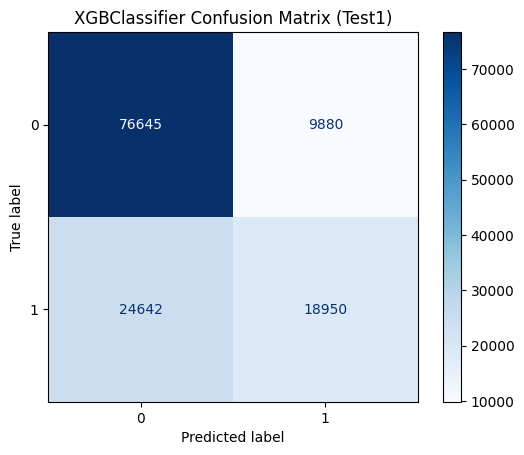

Classification Report for XGBClassifier (Test1):
              precision    recall  f1-score   support

           0       0.76      0.89      0.82     86525
           1       0.66      0.43      0.52     43592

    accuracy                           0.73    130117
   macro avg       0.71      0.66      0.67    130117
weighted avg       0.72      0.73      0.72    130117



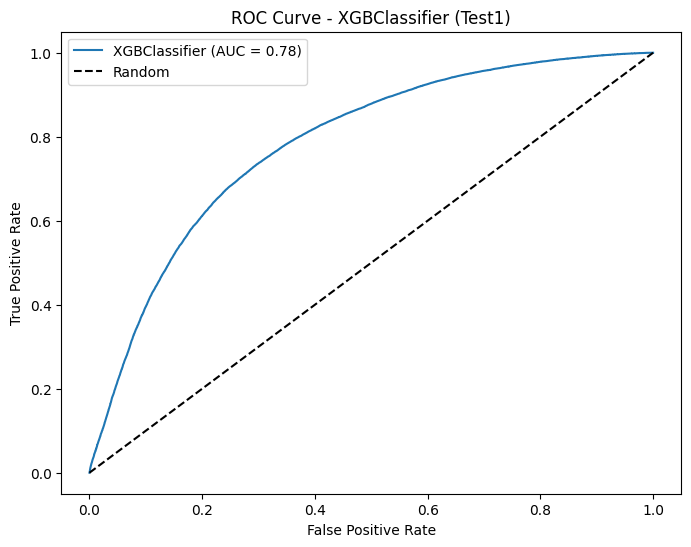

XGBClassifier - Test2 Accuracy: 0.764


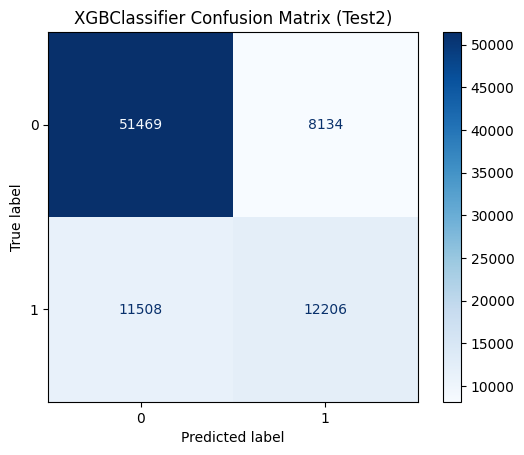

Classification Report for XGBClassifier (Test2):
              precision    recall  f1-score   support

           0       0.82      0.86      0.84     59603
           1       0.60      0.51      0.55     23714

    accuracy                           0.76     83317
   macro avg       0.71      0.69      0.70     83317
weighted avg       0.76      0.76      0.76     83317



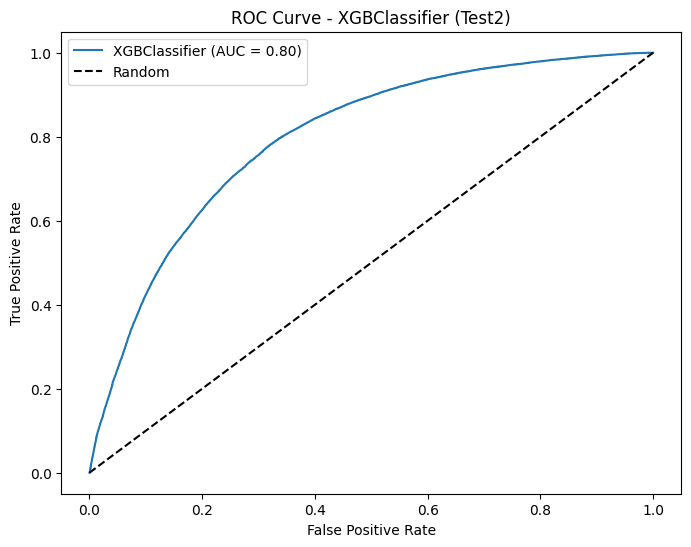

LogisticRegression - Train Accuracy: 0.754
LogisticRegression - Test1 Accuracy: 0.710


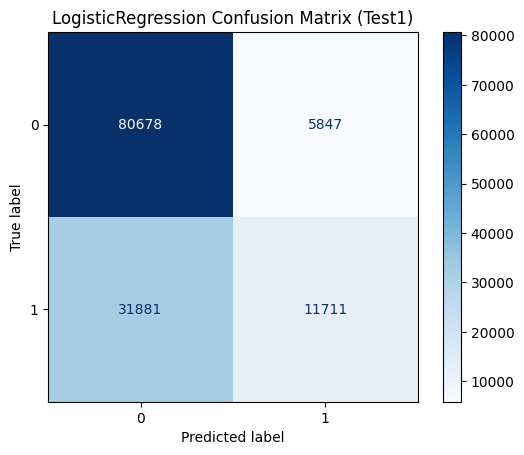

Classification Report for LogisticRegression (Test1):
              precision    recall  f1-score   support

           0       0.72      0.93      0.81     86525
           1       0.67      0.27      0.38     43592

    accuracy                           0.71    130117
   macro avg       0.69      0.60      0.60    130117
weighted avg       0.70      0.71      0.67    130117



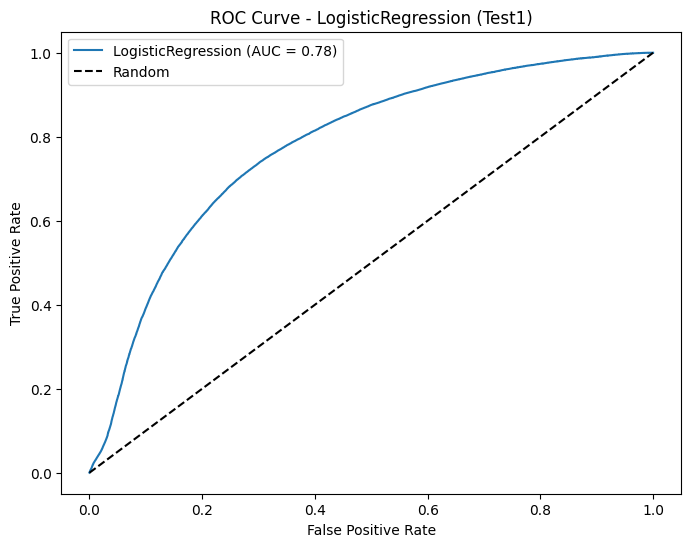

LogisticRegression - Test2 Accuracy: 0.757


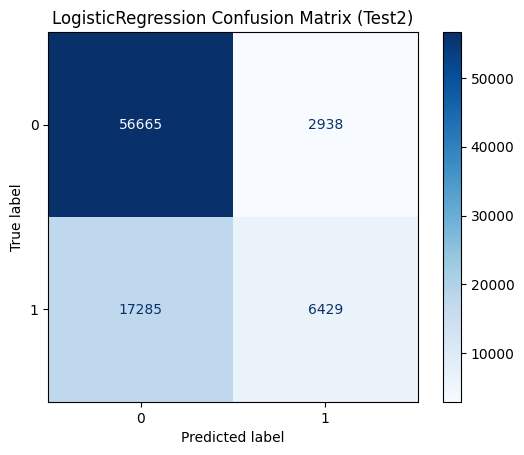

Classification Report for LogisticRegression (Test2):
              precision    recall  f1-score   support

           0       0.77      0.95      0.85     59603
           1       0.69      0.27      0.39     23714

    accuracy                           0.76     83317
   macro avg       0.73      0.61      0.62     83317
weighted avg       0.74      0.76      0.72     83317



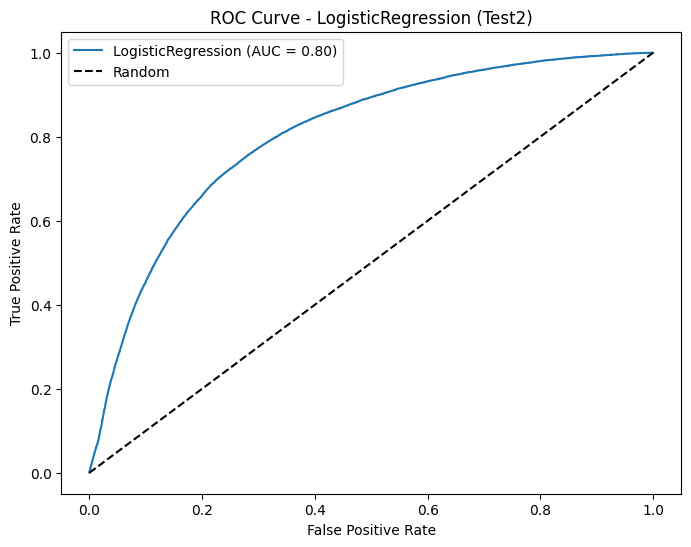

CatBoost - Train Accuracy: 0.810
CatBoostClassifier - Test1 Accuracy: 0.728


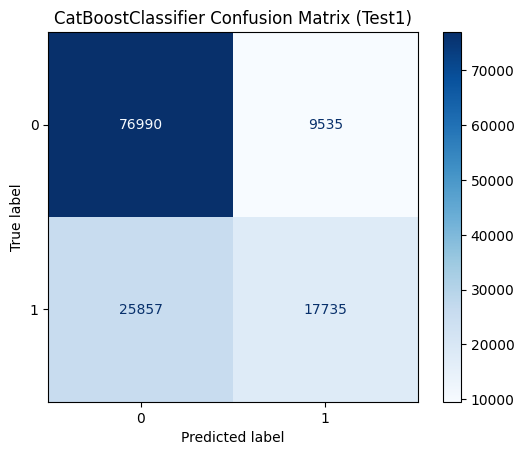

Classification Report for CatBoostClassifier (Test1):
              precision    recall  f1-score   support

           0       0.75      0.89      0.81     86525
           1       0.65      0.41      0.50     43592

    accuracy                           0.73    130117
   macro avg       0.70      0.65      0.66    130117
weighted avg       0.72      0.73      0.71    130117



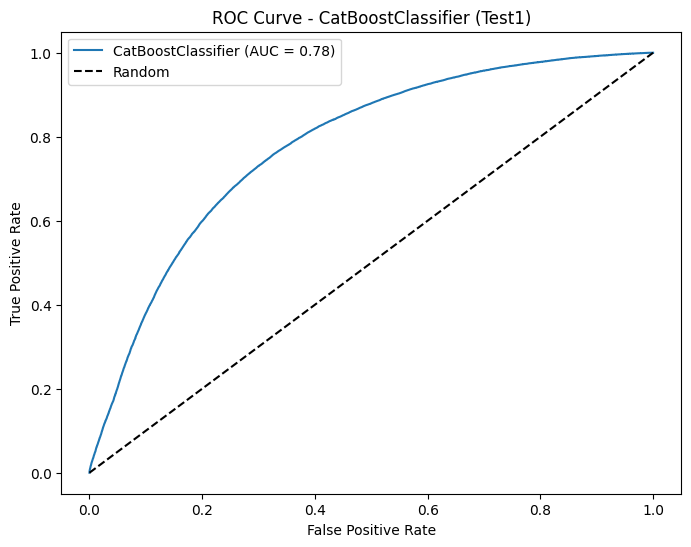

CatBoostClassifier - Test2 Accuracy: 0.756


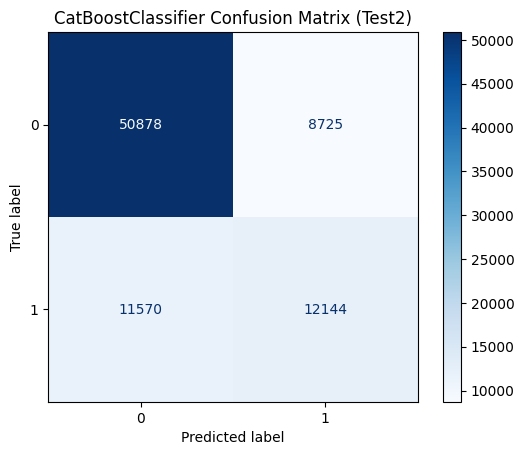

Classification Report for CatBoostClassifier (Test2):
              precision    recall  f1-score   support

           0       0.81      0.85      0.83     59603
           1       0.58      0.51      0.54     23714

    accuracy                           0.76     83317
   macro avg       0.70      0.68      0.69     83317
weighted avg       0.75      0.76      0.75     83317



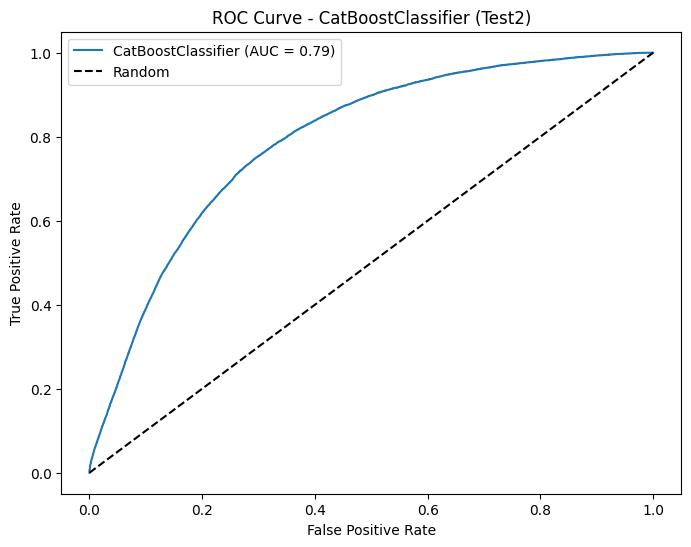

In [20]:
# Evaluate and compare baseline models, plot ROC curves, check for overfitting, and show confusion matrices
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay, classification_report

def evaluate_on_test(model, X, y, label):
    acc = model.score(X, y)
    print(f"{model.__class__.__name__} - {label} Accuracy: {acc:.3f}")
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'{model.__class__.__name__} Confusion Matrix ({label})')
    plt.show()
    print(f"Classification Report for {model.__class__.__name__} ({label}):")
    print(classification_report(y, y_pred))
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'{model.__class__.__name__} (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model.__class__.__name__} ({label})')
        plt.legend()
        plt.show()
    else:
        print(f"{model.__class__.__name__} does not support probability prediction for ROC curve.")

for name, model in models.items():
    train_acc = model.score(X_train, y_train)
    print(f"{name} - Train Accuracy: {train_acc:.3f}")
    evaluate_on_test(model, X_test1, y_test1, "Test1")
    evaluate_on_test(model, X_test2, y_test2, "Test2")


## 6. SMOTE and Cost-Sensitive Training

c:\Users\trymoren\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:50:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost (SMOTE) - Train Accuracy: 0.826
XGBClassifier - Test1 (SMOTE) Accuracy: 0.710


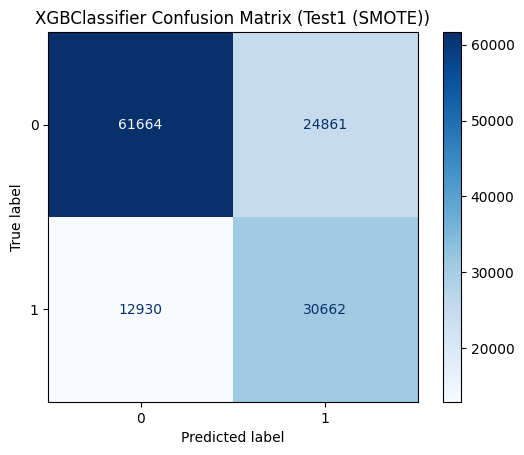

Classification Report for XGBClassifier (Test1 (SMOTE)):
              precision    recall  f1-score   support

           0       0.83      0.71      0.77     86525
           1       0.55      0.70      0.62     43592

    accuracy                           0.71    130117
   macro avg       0.69      0.71      0.69    130117
weighted avg       0.73      0.71      0.72    130117



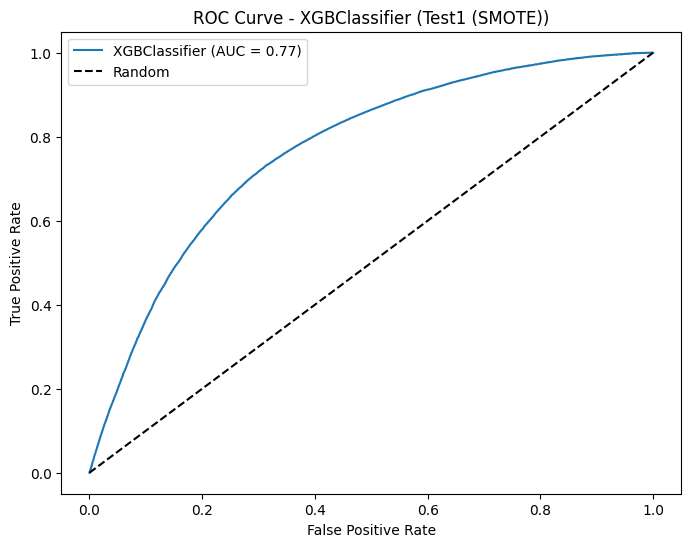

XGBClassifier - Test2 (SMOTE) Accuracy: 0.745


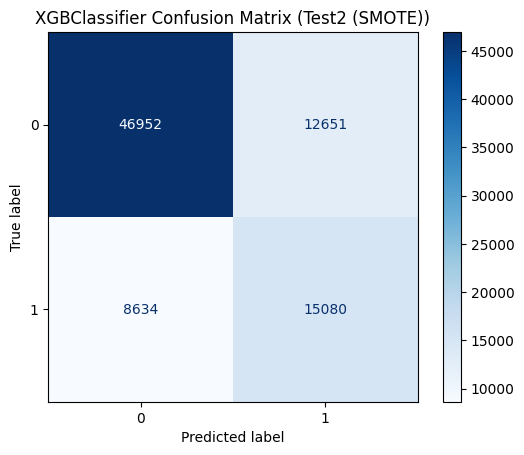

Classification Report for XGBClassifier (Test2 (SMOTE)):
              precision    recall  f1-score   support

           0       0.84      0.79      0.82     59603
           1       0.54      0.64      0.59     23714

    accuracy                           0.74     83317
   macro avg       0.69      0.71      0.70     83317
weighted avg       0.76      0.74      0.75     83317



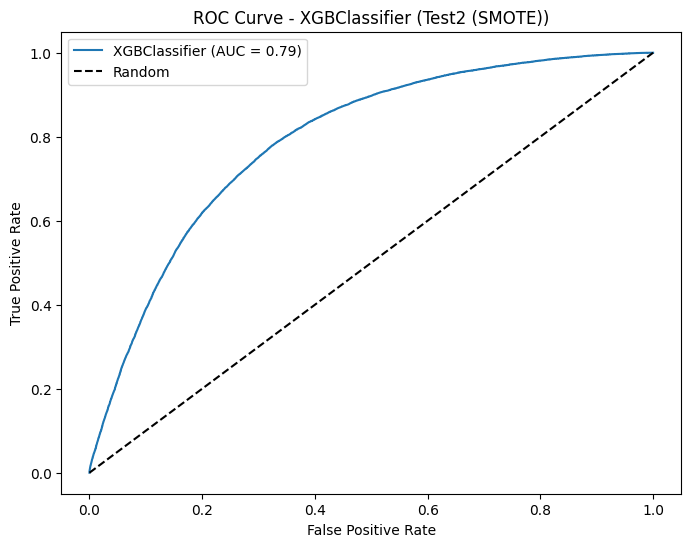

LogisticRegression (SMOTE) - Train Accuracy: 0.752
LogisticRegression - Test1 (SMOTE) Accuracy: 0.730


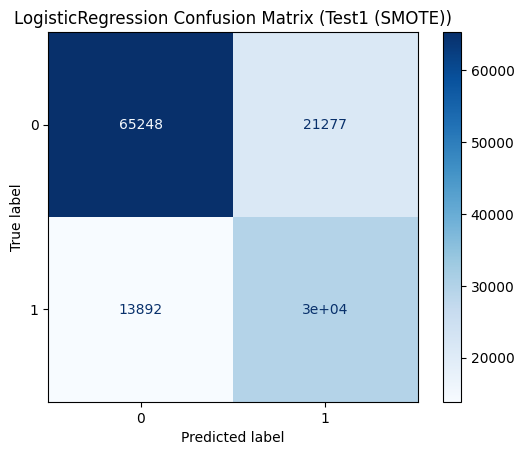

Classification Report for LogisticRegression (Test1 (SMOTE)):
              precision    recall  f1-score   support

           0       0.82      0.75      0.79     86525
           1       0.58      0.68      0.63     43592

    accuracy                           0.73    130117
   macro avg       0.70      0.72      0.71    130117
weighted avg       0.74      0.73      0.73    130117



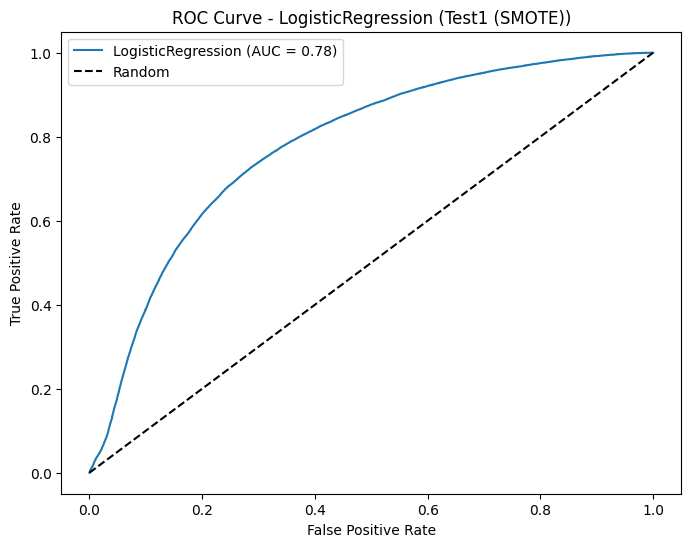

LogisticRegression - Test2 (SMOTE) Accuracy: 0.754


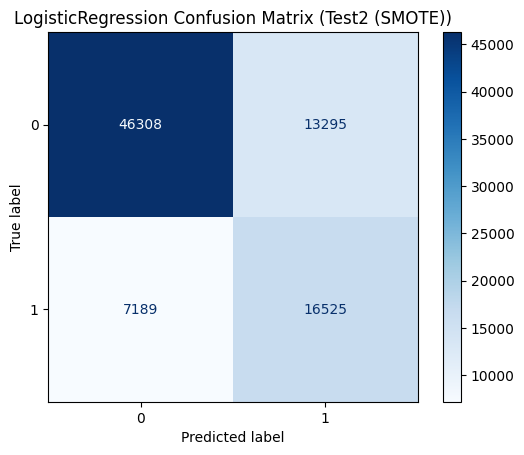

Classification Report for LogisticRegression (Test2 (SMOTE)):
              precision    recall  f1-score   support

           0       0.87      0.78      0.82     59603
           1       0.55      0.70      0.62     23714

    accuracy                           0.75     83317
   macro avg       0.71      0.74      0.72     83317
weighted avg       0.78      0.75      0.76     83317



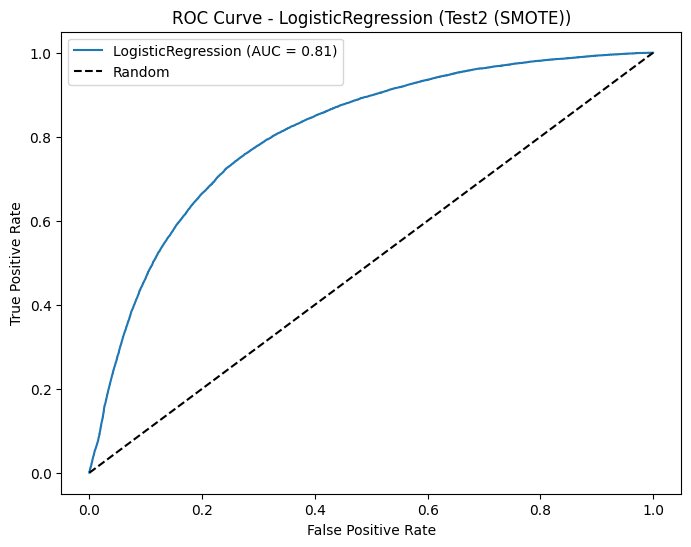

CatBoost (SMOTE) - Train Accuracy: 0.857
CatBoostClassifier - Test1 (SMOTE) Accuracy: 0.727


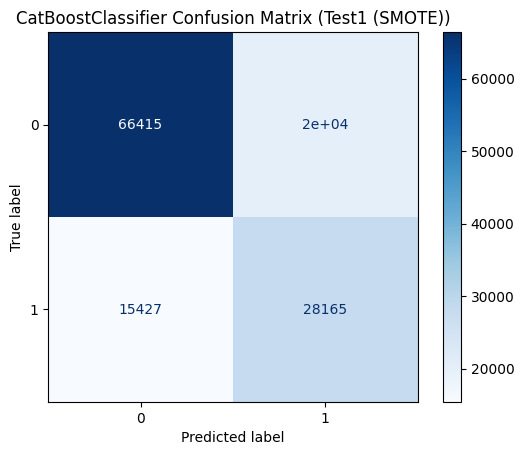

Classification Report for CatBoostClassifier (Test1 (SMOTE)):
              precision    recall  f1-score   support

           0       0.81      0.77      0.79     86525
           1       0.58      0.65      0.61     43592

    accuracy                           0.73    130117
   macro avg       0.70      0.71      0.70    130117
weighted avg       0.74      0.73      0.73    130117



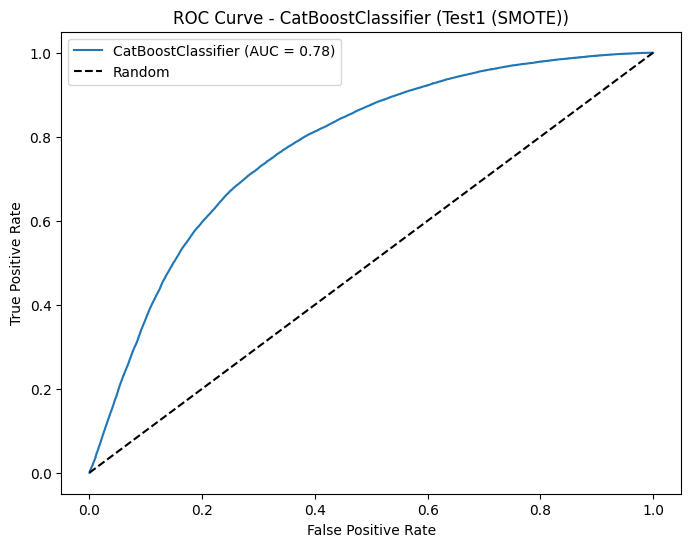

CatBoostClassifier - Test2 (SMOTE) Accuracy: 0.753


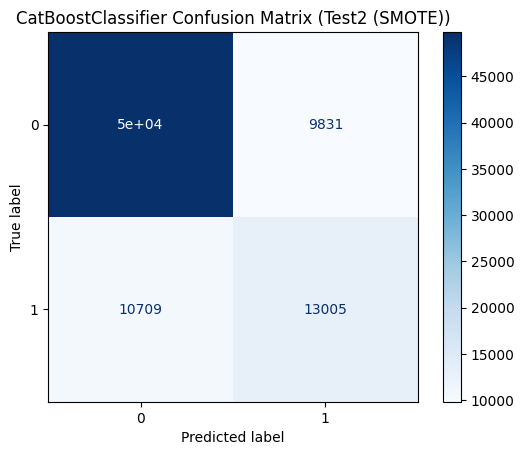

Classification Report for CatBoostClassifier (Test2 (SMOTE)):
              precision    recall  f1-score   support

           0       0.82      0.84      0.83     59603
           1       0.57      0.55      0.56     23714

    accuracy                           0.75     83317
   macro avg       0.70      0.69      0.69     83317
weighted avg       0.75      0.75      0.75     83317



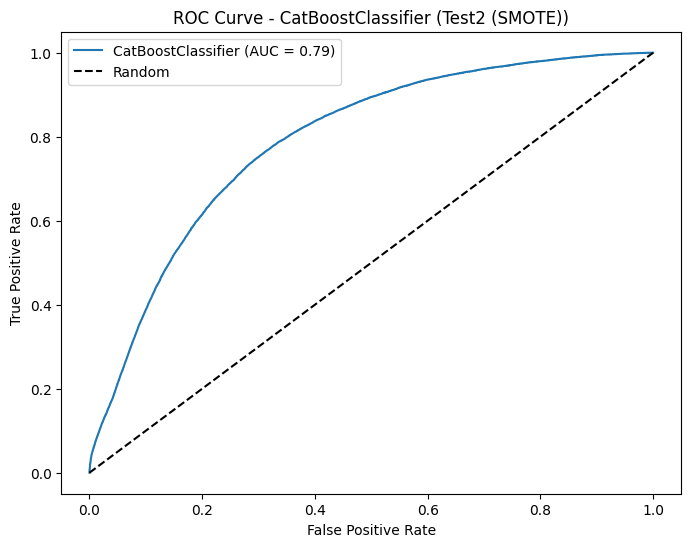

In [21]:
# Apply SMOTE and retrain models with cost-sensitive learning
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

models_smote = {
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(y_train_sm==0).sum()/(y_train_sm==1).sum(), random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    # 'SupportVector': SVC(probability=True, class_weight='balanced', random_state=42),  # SVM commented out for speed
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
    # 'RandomForest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42), # Uncomment to use Random Forest (takes longer)
}

def evaluate_on_test(model, X, y, label):
    acc = model.score(X, y)
    print(f"{model.__class__.__name__} - {label} Accuracy: {acc:.3f}")
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'{model.__class__.__name__} Confusion Matrix ({label})')
    plt.show()
    print(f"Classification Report for {model.__class__.__name__} ({label}):")
    print(classification_report(y, y_pred))
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'{model.__class__.__name__} (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model.__class__.__name__} ({label})')
        plt.legend()
        plt.show()
    else:
        print(f"{model.__class__.__name__} does not support probability prediction for ROC curve.")

for name, model in models_smote.items():
    model.fit(X_train_sm, y_train_sm)
    train_acc = model.score(X_train_sm, y_train_sm)
    print(f"{name} (SMOTE) - Train Accuracy: {train_acc:.3f}")
    evaluate_on_test(model, X_test1, y_test1, "Test1 (SMOTE)")
    evaluate_on_test(model, X_test2, y_test2, "Test2 (SMOTE)")


In [25]:
# Collect SMOTE model results for comparison and tuning
smote_results = {}
for name, model in models_smote.items():
    y_pred = model.predict(X_test1)
    y_proba = model.predict_proba(X_test1)[:, 1] if hasattr(model, 'predict_proba') else None
    smote_results[name] = {
        'accuracy': accuracy_score(y_test1, y_pred),
        'precision': precision_score(y_test1, y_pred),
        'recall': recall_score(y_test1, y_pred),
        'f1': f1_score(y_test1, y_pred),
        'roc_auc': roc_auc_score(y_test1, y_proba) if y_proba is not None else None,
        'confusion_matrix': confusion_matrix(y_test1, y_pred)
    }
# Convert results to DataFrame for easy selection
to_show = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
import pandas as pd
smote_results_df = pd.DataFrame(smote_results).T[to_show]
print(smote_results_df)


                    accuracy precision    recall        f1   roc_auc
XGBoost             0.709561   0.55224  0.703386  0.618716  0.768985
LogisticRegression  0.729712  0.582616  0.681318  0.628113  0.779894
CatBoost            0.726884  0.583428  0.646105  0.613169  0.776156


In [44]:
# # Display SMOTE results
# smote_results_df = pd.DataFrame(smote_results).T
# print(smote_results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']])
# for name, res in smote_results.items():
#     print(f"\n{name} (SMOTE) Confusion Matrix:")
#     plot_conf_matrix(res['confusion_matrix'], f"{name} (SMOTE) Confusion Matrix")

## 7. Hyperparameter Tuning for Best Model

Best model for tuning: LogisticRegression
Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\trymoren\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\trymoren\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 10}
Best F1 score (CV): 0.7276637606240423
Best Tuned Model - Train Accuracy: 0.752
LogisticRegression - Test1 (Tuned) Accuracy: 0.730


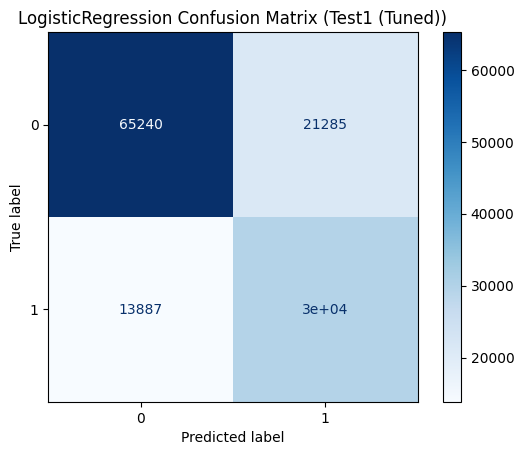

Classification Report for LogisticRegression (Test1 (Tuned)):
              precision    recall  f1-score   support

           0       0.82      0.75      0.79     86525
           1       0.58      0.68      0.63     43592

    accuracy                           0.73    130117
   macro avg       0.70      0.72      0.71    130117
weighted avg       0.74      0.73      0.73    130117



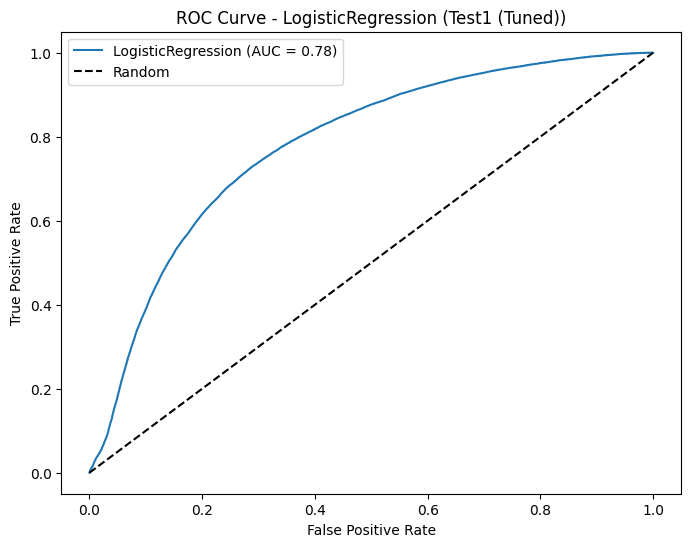

LogisticRegression - Test2 (Tuned) Accuracy: 0.754


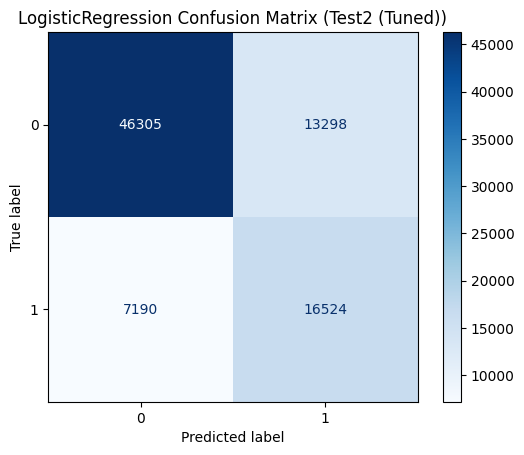

Classification Report for LogisticRegression (Test2 (Tuned)):
              precision    recall  f1-score   support

           0       0.87      0.78      0.82     59603
           1       0.55      0.70      0.62     23714

    accuracy                           0.75     83317
   macro avg       0.71      0.74      0.72     83317
weighted avg       0.78      0.75      0.76     83317



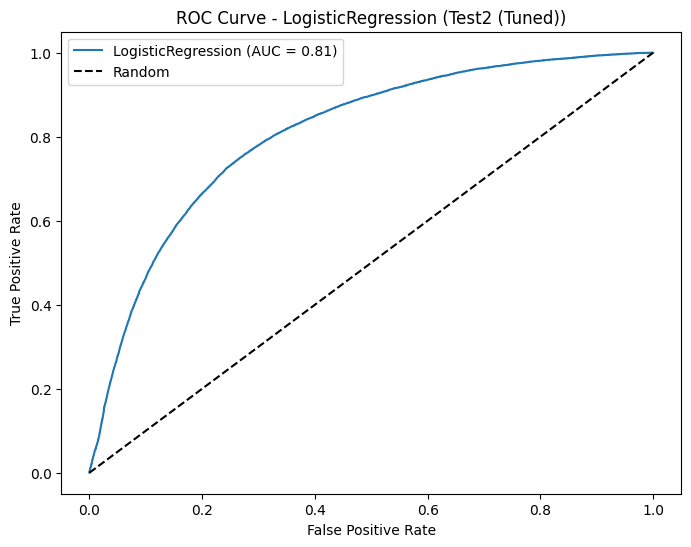

In [26]:
# Select best model based on F1 score 
allowed_models = ['XGBoost', 'LogisticRegression', 'CatBoost']  # SVM commented out for speed
available_results = smote_results_df.loc[smote_results_df.index.isin(allowed_models)]
best_model_name = available_results['f1'].idxmax()
print(f"Best model for tuning: {best_model_name}")

if best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'scale_pos_weight': [1, (y_train_sm==0).sum()/(y_train_sm==1).sum()]
    }
    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
elif best_model_name == 'LogisticRegression':
    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'saga'],
        'class_weight': ['balanced']
    }
    model = LogisticRegression(max_iter=1000, random_state=42)
# elif best_model_name == 'SupportVector':
#     param_grid = {
#         'C': [0.01, 0.1, 1, 10],
#         'kernel': ['linear', 'rbf', 'poly'],
#         'class_weight': ['balanced']
#     }
#     model = SVC(probability=True, random_state=42)
elif best_model_name == 'CatBoost':
    param_grid = {
        'iterations': [100, 200, 300],
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5]
    }
    model = CatBoostClassifier(verbose=0, random_state=42)
else:
    raise ValueError("Unknown model for tuning.")

tuner = RandomizedSearchCV(model, param_grid, n_iter=20, scoring='f1', cv=5, random_state=42, n_jobs=-1, verbose=2)
tuner.fit(X_train_sm, y_train_sm)
print(f"Best parameters: {tuner.best_params_}")
print(f"Best F1 score (CV): {tuner.best_score_}")
best_model = tuner.best_estimator_

def evaluate_on_test(model, X, y, label):
    acc = model.score(X, y)
    print(f"{model.__class__.__name__} - {label} Accuracy: {acc:.3f}")
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'{model.__class__.__name__} Confusion Matrix ({label})')
    plt.show()
    print(f"Classification Report for {model.__class__.__name__} ({label}):")
    print(classification_report(y, y_pred))
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'{model.__class__.__name__} (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model.__class__.__name__} ({label})')
        plt.legend()
        plt.show()
    else:
        print(f"{model.__class__.__name__} does not support probability prediction for ROC curve.")

# Evaluate best tuned model
train_acc = best_model.score(X_train_sm, y_train_sm)
print(f"Best Tuned Model - Train Accuracy: {train_acc:.3f}")
evaluate_on_test(best_model, X_test1, y_test1, "Test1 (Tuned)")
evaluate_on_test(best_model, X_test2, y_test2, "Test2 (Tuned)")


## 8. Advanced Optimization (Feature Selection, Ensembling, Calibration)

Feature importances not available for this model.
Install SHAP with 'pip install shap' to enable SHAP plots.


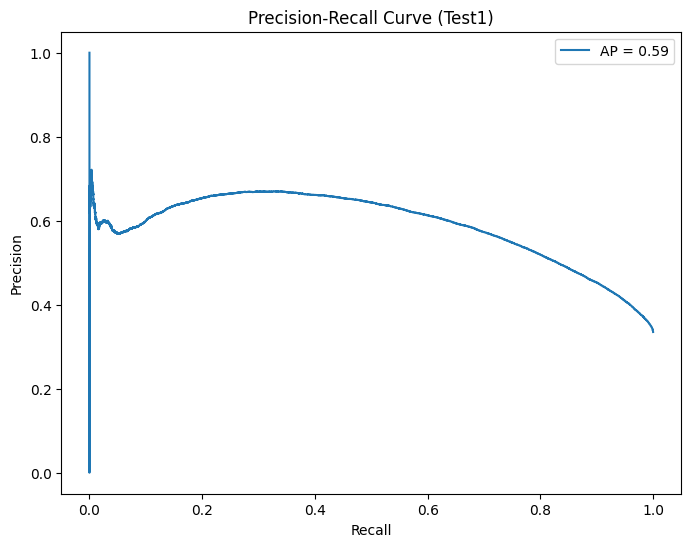

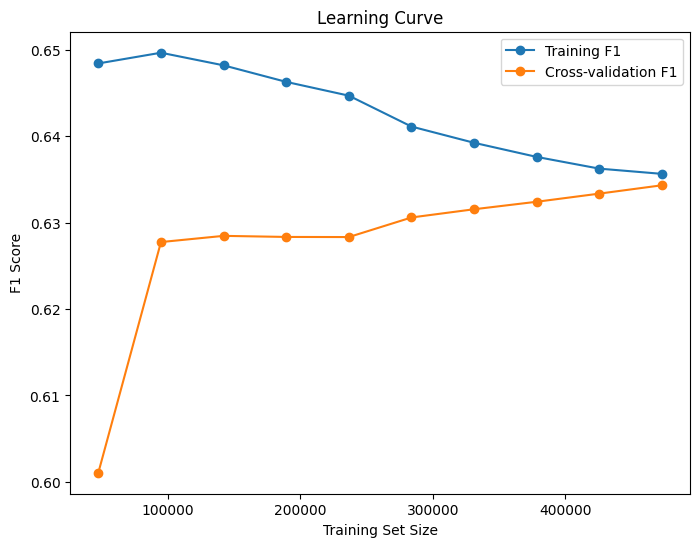

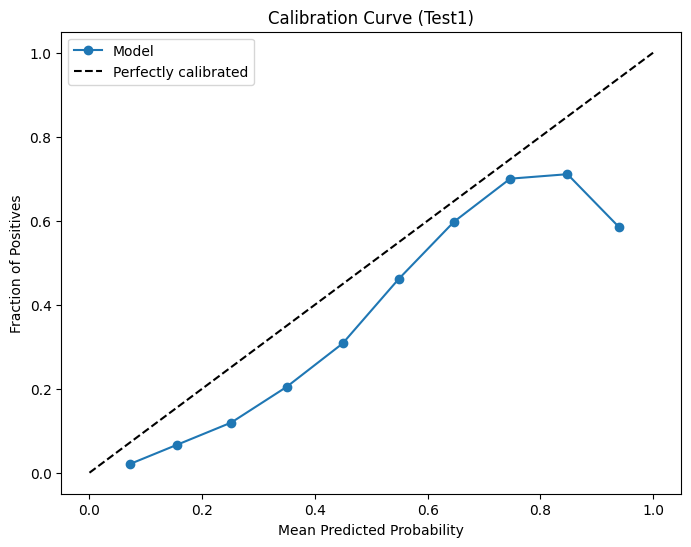

In [27]:
# --- 1. Feature Importance Plot (XGBoost or Random Forest) ---
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(10, 6))
    plt.title('Feature Importances')
    plt.bar(range(X_train.shape[1]), importances[indices], align='center')
    plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances not available for this model.")

# --- 2. SHAP Summary Plot ---
try:
    import shap
    explainer = shap.Explainer(best_model, X_train)
    shap_values = explainer(X_train)
    shap.summary_plot(shap_values, X_train, show=True)
except ImportError:
    print("Install SHAP with 'pip install shap' to enable SHAP plots.")
except Exception as e:
    print(f"SHAP plot error: {e}")

# --- 3. Precision-Recall Curve ---
from sklearn.metrics import precision_recall_curve, average_precision_score
if hasattr(best_model, 'predict_proba'):
    y_scores = best_model.predict_proba(X_test1)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test1, y_scores)
    avg_prec = average_precision_score(y_test1, y_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'AP = {avg_prec:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve (Test1)')
    plt.legend()
    plt.show()
else:
    print("Model does not support probability prediction for Precision-Recall curve.")

# --- 4. Learning Curve ---
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label='Training F1')
plt.plot(train_sizes, test_scores_mean, 'o-', label='Cross-validation F1')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Learning Curve')
plt.legend()
plt.show()

# --- 5. Calibration Curve ---
from sklearn.calibration import calibration_curve
if hasattr(best_model, 'predict_proba'):
    prob_true, prob_pred = calibration_curve(y_test1, best_model.predict_proba(X_test1)[:, 1], n_bins=10)
    plt.figure(figsize=(8, 6))
    plt.plot(prob_pred, prob_true, marker='o', label='Model')
    plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title('Calibration Curve (Test1)')
    plt.legend()
    plt.show()
else:
    print("Model does not support probability prediction for calibration curve.")


## 9. Final Evaluation on Test Set


All Models Ranked by F1 Score (Test1):
1. LogisticRegression | F1: 0.628 | Accuracy: 0.730 | Precision: 0.583 | Recall: 0.681 | ROC AUC: 0.7798937885800772
Confusion Matrix for LogisticRegression:
[[65248 21277]
 [13892 29700]]
------------------------------------------------------------


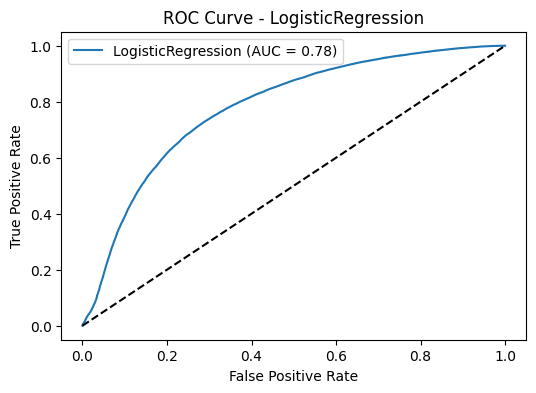


2. XGBoost | F1: 0.619 | Accuracy: 0.710 | Precision: 0.552 | Recall: 0.703 | ROC AUC: 0.7689850622427321
Confusion Matrix for XGBoost:
[[61664 24861]
 [12930 30662]]
------------------------------------------------------------


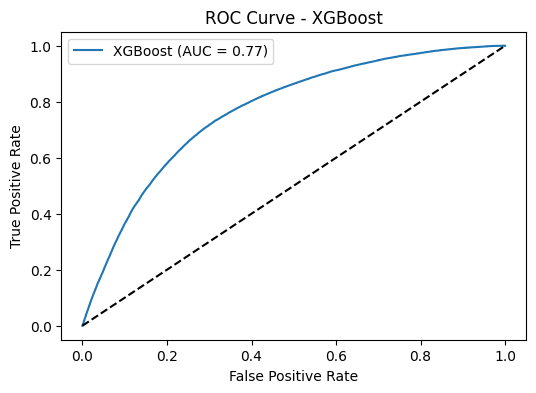


3. CatBoost | F1: 0.613 | Accuracy: 0.727 | Precision: 0.583 | Recall: 0.646 | ROC AUC: 0.7761556290212587
Confusion Matrix for CatBoost:
[[66415 20110]
 [15427 28165]]
------------------------------------------------------------


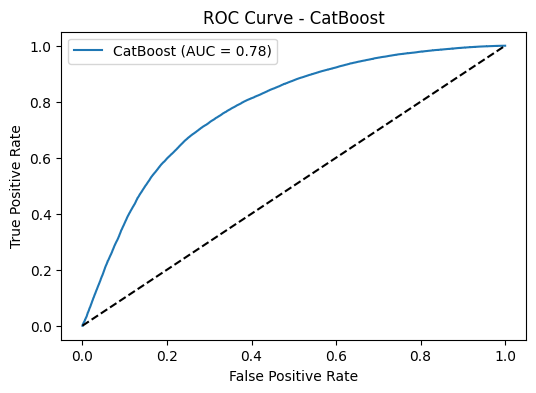



Best Model Type: LogisticRegression
Best Model - Train Accuracy: 0.752, Test Accuracy: 0.730
Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.82      0.75      0.79     86525
           1       0.58      0.68      0.63     43592

    accuracy                           0.73    130117
   macro avg       0.70      0.72      0.71    130117
weighted avg       0.74      0.73      0.73    130117



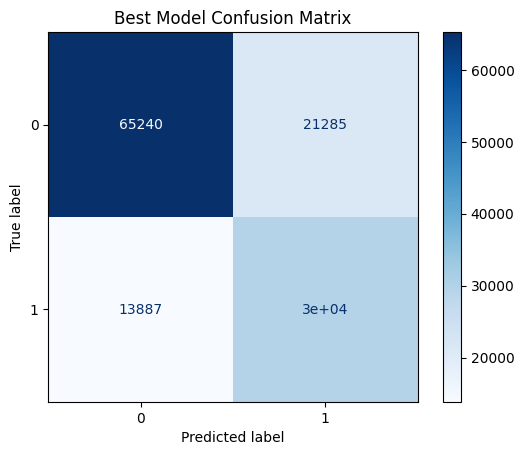

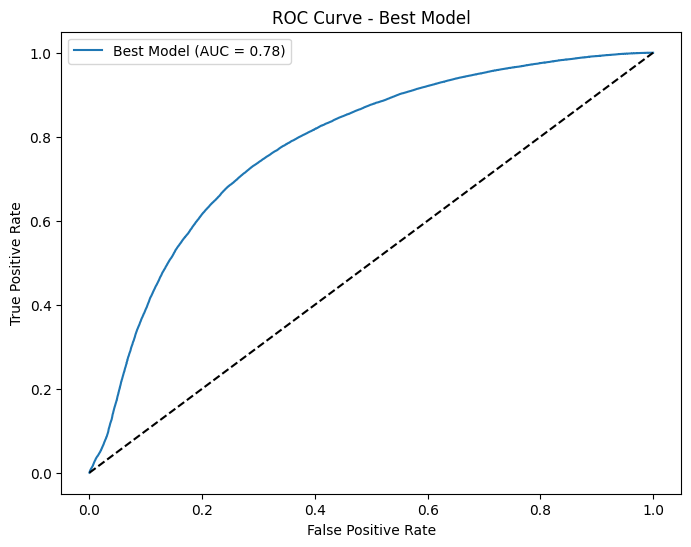

In [32]:
# --- Final Evaluation: Print all models ranked by F1 score, AUC, and Confusion Matrices ---
print("\nAll Models Ranked by F1 Score (Test1):")
ranked_models = smote_results_df.sort_values(by='f1', ascending=False)
for idx, (model_name, row) in enumerate(ranked_models.iterrows(), 1):
    print(f"{idx}. {model_name} | F1: {row['f1']:.3f} | Accuracy: {row['accuracy']:.3f} | Precision: {row['precision']:.3f} | Recall: {row['recall']:.3f} | ROC AUC: {row['roc_auc'] if not pd.isnull(row['roc_auc']) else 'N/A'}")
    # Print confusion matrix
    if 'confusion_matrix' in smote_results[model_name]:
        print(f"Confusion Matrix for {model_name}:")
        print(smote_results[model_name]['confusion_matrix'])
    print('-'*60)
    # Plot ROC curve for each model
    if not pd.isnull(row['roc_auc']) and hasattr(models_smote[model_name], 'predict_proba'):
        y_proba = models_smote[model_name].predict_proba(X_test1)[:, 1]
        fpr, tpr, _ = roc_curve(y_test1, y_proba)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {row['roc_auc']:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend()
        plt.show()
    else:
        print(f"{model_name} does not support probability prediction for ROC curve or ROC AUC is not available.")
    print()
# Continue with best model evaluation
# Ensure X_train_sm and X_test have identical columns and order for evaluation
train_cols = list(best_model.feature_names_in_) if hasattr(best_model, 'feature_names_in_') else list(X_train_sm.columns)
X_train_sm_aligned = X_train_sm.reindex(columns=train_cols, fill_value=0)
X_test_aligned = X_test1.reindex(columns=train_cols, fill_value=0)
y_test = y_test1
print(f"\nBest Model Type: {type(best_model).__name__}")
train_acc = best_model.score(X_train_sm_aligned, y_train_sm)
test_acc = best_model.score(X_test_aligned, y_test)
print(f"Best Model - Train Accuracy: {train_acc:.3f}, Test Accuracy: {test_acc:.3f}")
y_pred = best_model.predict(X_test_aligned)
print("Classification Report for Best Model:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Best Model Confusion Matrix')
plt.show()
if hasattr(best_model, 'predict_proba'):
    y_proba = best_model.predict_proba(X_test_aligned)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label='Best Model (AUC = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Best Model')
    plt.legend()
    plt.show()
else:
    print("Best model does not support probability prediction for ROC curve.")

In [101]:
# --- Align X_train_sm columns to X_test columns for calibrated model evaluation ---
X_train_sm = X_train_sm.reindex(columns=X_test.columns, fill_value=0)

In [99]:
# --- Align X_test columns to X_train_sm columns for calibrated model evaluation ---
X_test = X_test1.reindex(columns=X_train_sm.columns, fill_value=0)
y_test = y_test1

## 10. Save Best Model and Artifacts

In [ ]:
# Save the best model, scaler, and encoders
joblib.dump(calibrated_model, 'best_student_risk_model.pkl')
print('Saved best model as best_student_risk_model.pkl')